In [1]:
import os

# Set working directory to project root always`n
# Works regardless of where the notebook is saved`n
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
os.chdir(project_root)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\DELL\OneDrive\Documents\SRM\Churn_Analysis


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results = pd.read_csv('outputs/results/telecom_results.csv')
print("All Telecom results:")
print(results.to_string(index=False))

All Telecom results:
 Sector               Model  Accuracy  Precision  Recall     F1  ROC_AUC
Telecom Logistic Regression    0.8055     0.6582  0.5561 0.6029   0.8421
Telecom       Random Forest    0.7899     0.6291  0.5080 0.5621   0.8244
Telecom             XGBoost    0.7935     0.6436  0.4973 0.5611   0.8401


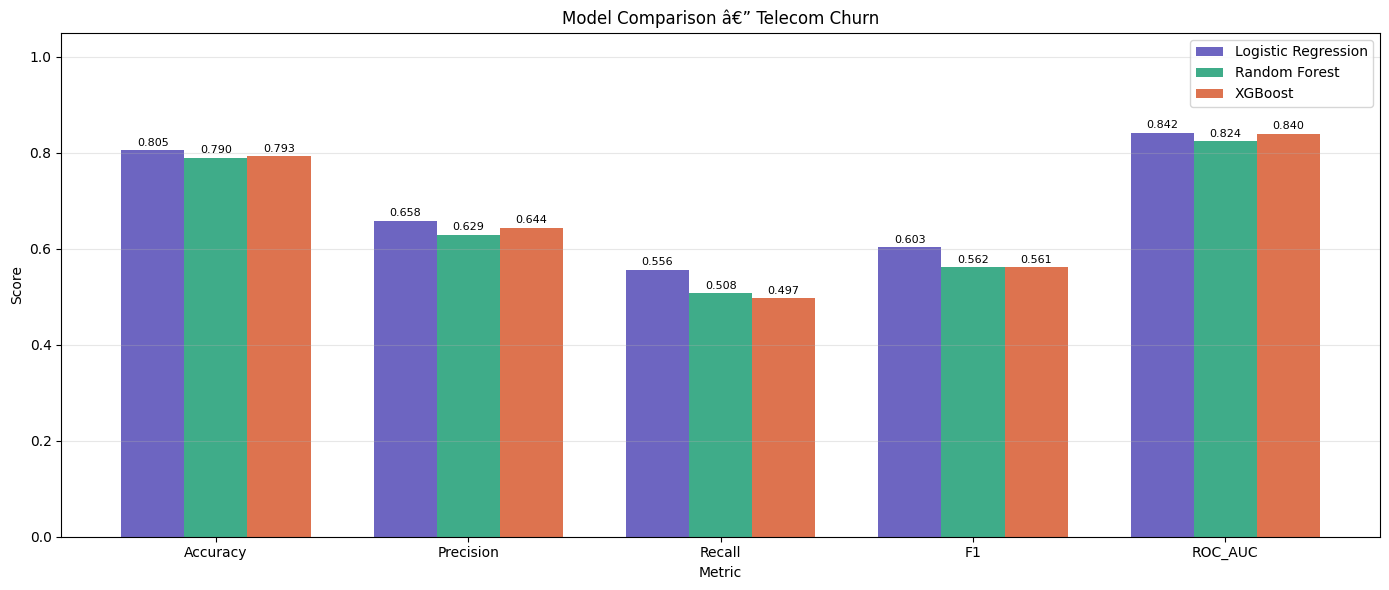

In [3]:
metrics = ['Accuracy','Precision','Recall','F1','ROC_AUC']
models  = results['Model'].tolist()

x = np.arange(len(metrics))
width = 0.25
colors = ['#534AB7','#1D9E75','#D85A30']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    vals = results[results['Model']==model][metrics].values[0]
    bars = ax.bar(x + i*width, vals, width,
                  label=model, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8
        )

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Comparison â€” Telecom Churn')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    'outputs/plots/telecom/12_model_comparison.png',
    bbox_inches='tight'
)
plt.show()

In [4]:
print("Best model per metric:")
print("-"*35)
for metric in metrics:
    best_idx = results[metric].idxmax()
    best_model = results.loc[best_idx, 'Model']
    best_score = results.loc[best_idx, metric]
    print(f"  {metric:<12}: {best_model:<22} ({best_score:.4f})")

Best model per metric:
-----------------------------------
  Accuracy    : Logistic Regression    (0.8055)
  Precision   : Logistic Regression    (0.6582)
  Recall      : Logistic Regression    (0.5561)
  F1          : Logistic Regression    (0.6029)
  ROC_AUC     : Logistic Regression    (0.8421)


c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


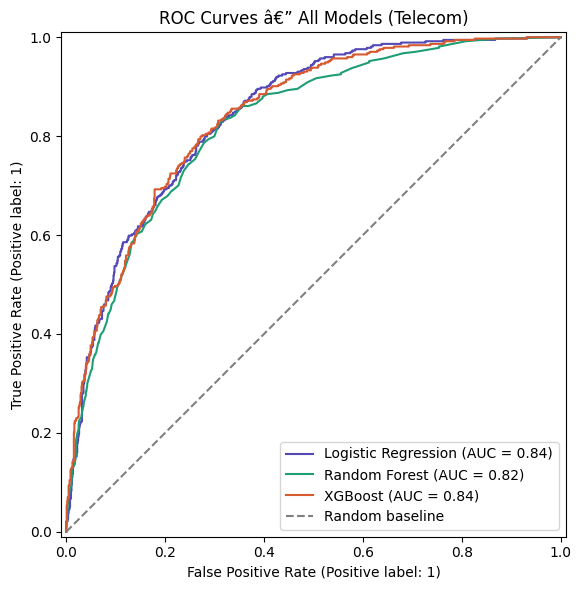

In [5]:
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay

# Load data
X_train = np.load('outputs/X_train_telecom.npy')
X_test  = np.load('outputs/X_test_telecom.npy')
y_train = np.load('outputs/y_train_telecom.npy')
y_test  = np.load('outputs/y_test_telecom.npy')

# Retrain all 3
lr  = LogisticRegression(max_iter=1000, random_state=42)
rf  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1,
                    max_depth=4, random_state=42,
                    use_label_encoder=False,
                    eval_metric='logloss', verbosity=0)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# Plot all 3 ROC curves
fig, ax = plt.subplots(figsize=(8, 6))

for model, name, color in [
    (lr,  'Logistic Regression', '#534AB7'),
    (rf,  'Random Forest',       '#1D9E75'),
    (xgb, 'XGBoost',             '#D85A30'),
]:
    proba = model.predict_proba(X_test)[:,1]
    RocCurveDisplay.from_predictions(
        y_test, proba, ax=ax,
        name=name, color=color
    )

ax.plot([0,1],[0,1],'--',color='gray',label='Random baseline')
ax.set_title('ROC Curves â€” All Models (Telecom)')
ax.legend()
plt.tight_layout()
plt.savefig(
    'outputs/plots/telecom/13_all_roc_curves.png',
    bbox_inches='tight'
)
plt.show()

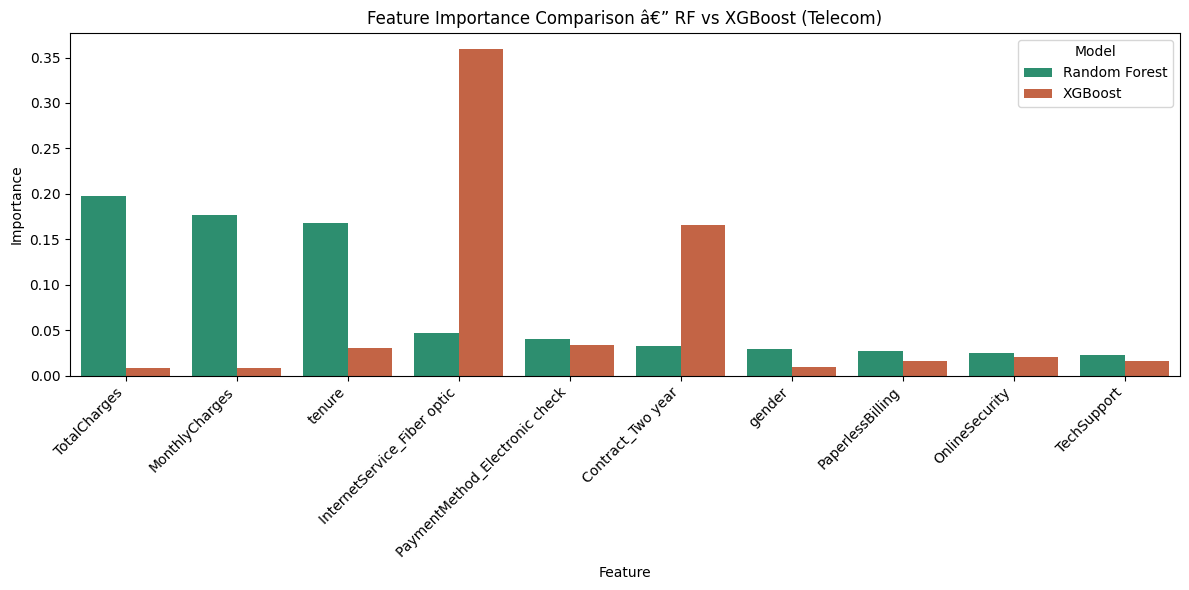

In [6]:
import pandas as pd
import seaborn as sns

feature_names = pd.read_csv(
    'outputs/telecom_feature_names.csv'
).squeeze().tolist()

rf_imp  = rf.feature_importances_
xgb_imp = xgb.feature_importances_

feat_compare = pd.DataFrame({
    'Feature'       : feature_names,
    'Random Forest' : rf_imp,
    'XGBoost'       : xgb_imp
}).sort_values('Random Forest', ascending=False).head(10)

feat_compare_melted = feat_compare.melt(
    id_vars='Feature',
    var_name='Model',
    value_name='Importance'
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=feat_compare_melted,
    x='Feature', y='Importance',
    hue='Model',
    palette=['#1D9E75','#D85A30']
)
plt.title('Feature Importance Comparison â€” RF vs XGBoost (Telecom)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(
    'outputs/plots/telecom/14_feature_importance_comparison.png',
    bbox_inches='tight'
)
plt.show()